---
Title: "Economic Impacts of Migration"
---

<!-- You have to develop your own headline structure. -->

## Headline 1
Analysis of Migration and Remittance Dynamics in Nigeria (2000–2020): 
## Headline 2
Scaling,
Correlation, and 
Policy Efficiency

   Year  total_remittances  number_of_migrants
0  2000       1.052142e+06               83822
1  2005       6.803027e+07              125003
2  2010       4.747469e+07              189847
3  2015       1.035451e+09              236603
4  2020       9.210166e+07              286251
Index(['Year', 'total_remittances', 'number_of_migrants'], dtype='str')

Correlation between Remittances and Migrants: 0.22


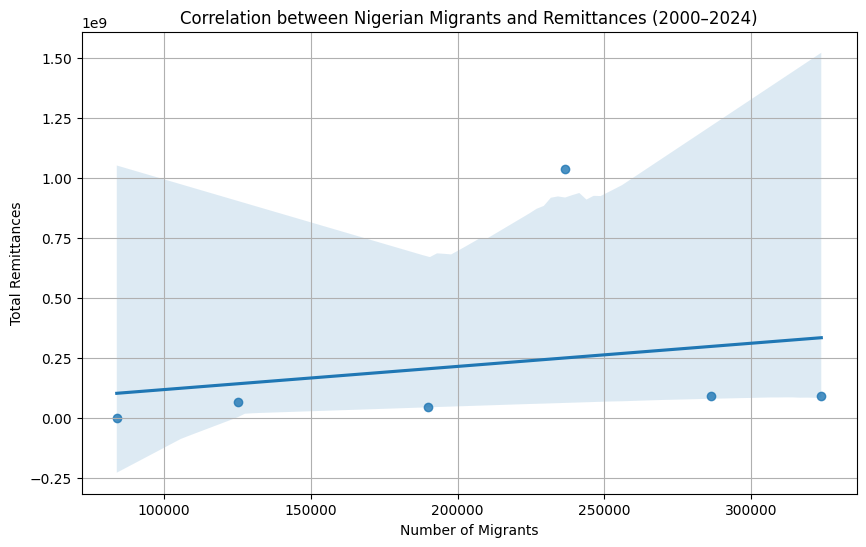

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# File path (your merged dataset)
file_path = r"C:\Users\ZIZIPHO\Desktop\MSc Data Engineering\Python Programming for DE\Tutorials\Fundamentals_PythonNtshatsha\DataScienceLab_Migration\data_processed\merged_migration_remittances 1(in).csv"

# Load the merged data
df = pd.read_csv(file_path)

# Inspect data
print(df.head())
print(df.columns)

# Clean column names (strip spaces and convert to lowercase with underscores)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Make sure correct data types
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['total_remittances'] = pd.to_numeric(df['total_remittances'], errors='coerce')
df['number_of_migrants'] = pd.to_numeric(df['number_of_migrants'], errors='coerce')

# Drop missing values
df = df.dropna()

# Correlation
correlation = df['total_remittances'].corr(df['number_of_migrants'])
print(f"\nCorrelation between Remittances and Migrants: {correlation:.2f}")

# Plot
plt.figure(figsize=(10, 6))
sns.regplot(
    x=df['number_of_migrants'], 
    y=df['total_remittances'], 
    marker='o'
)

plt.title('Correlation between Nigerian Migrants and Remittances (2000–2024)')
plt.xlabel('Number of Migrants')
plt.ylabel('Total Remittances')
plt.grid(True)
plt.show()

The graph shows a weak positive relationship between the number of migrants and total remittances. Each point represents a specific year, plotting migration against remittance inflows. The upward-sloping trend line suggests that remittances tend to increase as migration rises. However, the low correlation coefficient (0.22) indicates that this relationship is not strong. The wide spread of points and the large confidence interval suggest that other factors, beyond migration, significantly influence remittance flows.

Reason for the spike in 2015?

In 2015:
Nigeria faced falling oil prices (major income source) and coursed Economic uncertainty.
Global evidence shows that low oil prices and economic stress affect remittance behavior (world bank)

In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# data
data = {
    'Year': [2000, 2005, 2010, 2015, 2020],
    'total_remittances': [1.052142e6, 6.803027e7, 4.747469e7, 1.035451e9, 9.210166e7],
    'number_of_migrants': [83822, 125003, 189847, 236603, 286251]
}

df = pd.DataFrame(data)

# scale
scaler = MinMaxScaler()
df_scaled = df.copy()

df_scaled[['remittances_scaled', 'migrants_scaled']] = scaler.fit_transform(
    df[['total_remittances', 'number_of_migrants']]
)

#policy index (weighted)
df_scaled['Policy_Index'] = (
    0.7 * df_scaled['remittances_scaled']
    - 0.3 * df_scaled['migrants_scaled']
)

print(df_scaled)

   Year  total_remittances  number_of_migrants  remittances_scaled  \
0  2000       1.052142e+06               83822            0.000000   
1  2005       6.803027e+07              125003            0.064751   
2  2010       4.747469e+07              189847            0.044879   
3  2015       1.035451e+09              236603            1.000000   
4  2020       9.210166e+07              286251            0.088022   

   migrants_scaled  Policy_Index  
0         0.000000      0.000000  
1         0.203434     -0.015705  
2         0.523764     -0.125714  
3         0.754739      0.473578  
4         1.000000     -0.238385  


The policy index assigns a weight of 70% to remittances and 30% to migration, reflecting the assumption that economic gains are more important than the costs associated with human migration. The negative sign for migration indicates that higher migration is treated as a loss.

The results show that 2015 achieved the highest policy efficiency, as strong remittance inflows outweighed the costs of migration. In contrast, 2020 recorded the lowest score, indicating that high migration was not matched by sufficient financial returns. Overall, the findings suggest that migration only contributes positively to policy outcomes when it generates substantial economic benefits.